# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
!git clone https://github.com/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP

Cloning into 'Flyrank-ML-INTERNSHIP'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 131 (delta 43), reused 94 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.86 MiB | 6.62 MiB/s, done.
Resolving deltas: 100% (43/43), done.



## 1. Method choice and why

The modeling task is a multiclass classification problem. The target variable is `trend_direction`, which contains five classes: down, stable, up, new, and flat.

I chose a Decision Tree as the initial model because it can naturally handle multiclass classification and is relatively easy to interpret. It can also capture non-linear relationships between content and performance signals without requiring feature scaling.

I will first check the available features for possible target leakage before training. The model will be evaluated against the Week-4 baseline using the same evaluation setup. Model complexity will only be considered useful if it produces a meaningful improvement over the baseline.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd

DATA_PATH = "Flyrank-ML-INTERNSHIP/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [9]:
print("Target classes:")
print(df["trend_direction"].value_counts())

print("\nPotential trend-related columns:")
print([
    col for col in df.columns
    if "trend" in col.lower()
])

Target classes:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Potential trend-related columns:
['trend_direction', 'trend_pct']


In [8]:
print(df["trend_direction"].value_counts(dropna=False))

trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64


In [10]:
print("Potential trend-related columns:")
print([
    col for col in df.columns
    if "trend" in col.lower()
])

Potential trend-related columns:
['trend_direction', 'trend_pct']


## 2. Split design
### Split design

I used an 80/20 train-test split with stratification on `trend_direction`. The training data is used to fit the model, while the test data is kept separate for evaluation.

Stratification was used because the five target classes are imbalanced. This helps preserve approximately the same class proportions in both the training and test sets. I used `random_state=42` so the split is reproducible.

Missing values were identified before modeling. They will be handled inside the preprocessing pipeline after the split so that information from the test set is not used during training.


In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
target = "trend_direction"

features = [
    "content_age_days",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (30000, 26)
y shape: (30000,)


In [12]:
print("Missing values:")
print(X.isna().sum().sort_values(ascending=False).head(10))

Missing values:
word_count          7699
char_count          7699
cpc                 2468
search_volume       2468
competition         2468
scroll_rate          125
impressions_90d        0
clicks_90d             0
pageviews_90d          0
content_age_days       0
dtype: int64


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 24000
Testing rows: 6000


In [14]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training class distribution:
trend_direction
down      0.542
stable    0.199
up        0.146
new       0.075
flat      0.038
Name: proportion, dtype: float64

Test class distribution:
trend_direction
down      0.542
stable    0.199
up        0.146
new       0.074
flat      0.038
Name: proportion, dtype: float64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*
### Model vs baseline interpretation

The Decision Tree outperformed the Week-4 baseline on the Top-20 down-rate measure. The Week-4 baseline had a Top-20 down rate of 0.55, while the Decision Tree achieved 1.00.

This means that 11 of the baseline's top 20 pages were actually in the `down` trend class, compared with 20 of the Decision Tree's top 20 pages. This suggests that the model provides a stronger ranking signal for identifying potentially declining content.

However, this result should not be interpreted as proof that the model will always outperform the baseline. The comparison was performed on one held-out test split, and the smaller `flat` and `new` classes should also be considered when interpreting the overall model performance.

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

model.fit(X_train, y_train)

print("Decision Tree trained successfully.")


Decision Tree trained successfully.


In [16]:
y_pred = model.predict(X_test)

print("Predictions created.")
print(y_pred[:20])

Predictions created.
['up' 'down' 'down' 'flat' 'down' 'new' 'down' 'down' 'down' 'down' 'new'
 'down' 'down' 'down' 'flat' 'flat' 'up' 'down' 'down' 'down']


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(accuracy, 4))
print("Macro Precision:", round(precision, 4))
print("Macro Recall   :", round(recall, 4))
print("Macro F1       :", round(f1, 4))

Decision Tree Results
---------------------
Accuracy : 0.676
Macro Precision: 0.7284
Macro Recall   : 0.6537
Macro F1       : 0.6544


In [18]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

        down       0.66      0.93      0.77      3252
        flat       1.00      1.00      1.00       231
         new       1.00      1.00      1.00       447
      stable       0.42      0.15      0.22      1192
          up       0.56      0.18      0.28       878

    accuracy                           0.68      6000
   macro avg       0.73      0.65      0.65      6000
weighted avg       0.64      0.68      0.62      6000



In [20]:
print([col for col in df.columns if "baseline" in col.lower()])

[]


In [21]:
print([col for col in df.columns if "refresh" in col.lower()])

[]


In [22]:
!grep -R "Baseline scoring inputs" -n Flyrank-ML-INTERNSHIP/work/

Flyrank-ML-INTERNSHIP/work/notebooks/w04_baseline_score.ipynb:3463:        "print(\"Baseline scoring inputs:\")\n",
Flyrank-ML-INTERNSHIP/work/notebooks/w04_baseline_score.ipynb:3490:            "Baseline scoring inputs:\n",


In [23]:
import json

w04_path = "Flyrank-ML-INTERNSHIP/work/notebooks/w04_baseline_score.ipynb"

with open(w04_path, "r", encoding="utf-8") as f:
    w04 = json.load(f)

for i, cell in enumerate(w04["cells"]):
    source = "".join(cell.get("source", []))

    if "baseline" in source.lower() or "Baseline" in source:
        print("\n" + "="*80)
        print("CELL", i)
        print("="*80)
        print(source)


CELL 0
# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

CELL 1
## 1. My rule and its reason codes

*Write the rule in plain words first. Then the reason codes it can output.*
### Rule

I will prioritize pages for content refresh when they show stronger evidence of
being stale while still having meaningful search opportunity.

The baseline uses two observable signals:

1. Content age — used as the staleness signal.
2. Search visibility — used as the opportunity signal.

The score combines the two signals 

In [24]:
for i, cell in enumerate(w04["cells"]):
    source = "".join(cell.get("source", []))

    if any(word in source.lower() for word in [
        "precision",
        "recall",
        "metric",
        "evaluation",
        "evaluate",
        "top-20",
        "top20"
    ]):
        print("\n" + "="*80)
        print("CELL", i)
        print("="*80)
        print(source)


CELL 0
# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aniqaatiq842-commits/Flyrank-ML-INTERNSHIP/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

CELL 19
## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

CELL 20
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
top20 = queue.head(20).copy()

top20_review = []

for _, row in top20.iterrows():

    if row["baseline_score"] >= 4:
        confidence_note = "High baseline priority"
    eli

In [25]:
# Get probability for each trend class
class_names = model.named_steps["tree"].classes_

print("Classes:", class_names)

Classes: ['down' 'flat' 'new' 'stable' 'up']


In [26]:
down_index = list(class_names).index("down")

down_probability = model.predict_proba(X_test)[:, down_index]

print(down_probability[:10])

[0.18642447 0.39796782 0.7331101  0.         0.7331101  0.
 0.57845433 0.39796782 0.57845433 0.44648188]


In [27]:
model_results = X_test.copy()

model_results["actual_trend"] = y_test.values
model_results["predicted_trend"] = y_pred
model_results["down_probability"] = down_probability

model_results = model_results.sort_values(
    "down_probability",
    ascending=False
)

display(model_results.head(20))

,content_age_days,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,...,sessions_prev_30d,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,actual_trend,predicted_trend,down_probability
5755,223,0.0,0.00,0.00,1498.0,9499.0,3,0,2,2,...,2,20,0.00,10.3,0.00,0.00,0.0,down,down,1.0
23915,271,20.0,0.02,0.00,1582.0,9833.0,2,0,2,2,...,1,20,0.00,7.0,0.00,50.00,0.0,down,down,1.0
11446,189,0.0,0.00,0.00,4869.0,34296.0,16,0,7,7,...,5,20,0.00,4.9,0.00,28.57,0.0,down,down,1.0
4330,98,70.0,0.20,1.82,2805.0,19206.0,6,0,3,3,...,2,8,0.00,18.2,0.00,66.67,0.0,down,down,1.0
29562,90,0.0,0.00,0.00,2800.0,19230.0,11,0,2,2,...,1,8,0.00,9.5,0.00,0.00,0.0,down,down,1.0
5848,98,590.0,0.64,2.05,2528.0,16538.0,548,0,3,3,...,2,8,0.00,7.0,0.00,33.33,0.0,down,down,1.0
3110,117,0.0,0.00,0.00,2780.0,20087.0,10,0,3,3,...,2,8,0.00,4.0,0.00,0.00,0.0,down,down,1.0
2307,463,90.0,0.10,0.00,NaN,NaN,29,0,4,4,...,2,22,0.00,35.5,0.00,0.00,0.0,down,down,1.0
12554,153,50.0,0.97,2.37,3234.0,22120.0,5,0,1,1,...,1,8,0.00,18.4,0.00,100.00,0.0,down,down,1.0
11087,463,30.0,0.26,1.16,NaN,NaN,19,0,1,1,...,0,22,0.00,36.1,0.00,0.00,0.0,down,down,1.0


In [33]:
import numpy as np

baseline_test = df.loc[X_test.index].copy()

# Exact Week-4 age score
baseline_test["age_score"] = np.select(
    [
        baseline_test["content_age_days"] < 180,
        baseline_test["content_age_days"] < 360,
        baseline_test["content_age_days"] >= 360
    ],
    [
        0,
        1,
        2
    ],
    default=0
)

# Exact Week-4 CTR opportunity rule
baseline_test["ctr_opportunity"] = (
    (baseline_test["avg_position"] <= 10) &
    (baseline_test["ctr"] < 0.05)
)

# Exact Week-4 CTR score
baseline_test["ctr_score"] = np.where(
    baseline_test["ctr_opportunity"],
    2,
    0
)

# Exact Week-4 baseline score
baseline_test["baseline_score"] = (
    baseline_test["age_score"] +
    baseline_test["ctr_score"]
)

# Rank baseline
baseline_test = baseline_test.sort_values(
    ["baseline_score", "age_score", "ctr_score"],
    ascending=[False, False, False]
)

print("Baseline test-set rows:", len(baseline_test))

display(
    baseline_test[
        [
            "content_id",
            "trend_direction",
            "baseline_score",
            "age_score",
            "ctr_score",
            "content_age_days",
            "ctr",
            "avg_position"
        ]
    ].head(20)
)

Baseline test-set rows: 6000


,content_id,trend_direction,baseline_score,age_score,ctr_score,content_age_days,ctr,avg_position
27519,content_2bbb0ed9e593,flat,4,2,2,495,0.00,5.0
29508,content_85bf6763d5c5,down,4,2,2,421,0.00,10.0
11609,content_0feda4547722,down,4,2,2,502,0.00,7.5
2444,content_bc3c2360d9fc,flat,4,2,2,494,0.00,8.1
9765,content_70a28e3eaa24,down,4,2,2,466,0.00,9.9
2795,content_902156d012c4,flat,4,2,2,494,0.00,5.5
23996,content_a4b6bb9bfca9,down,4,2,2,421,0.00,5.8
14258,content_619df74dd3a1,up,4,2,2,362,0.00,4.5
3163,content_eb7015b56be9,stable,4,2,2,545,0.00,9.1
12555,content_1c8ae05abbfa,down,4,2,2,375,0.00,4.9


In [34]:
baseline_top20 = baseline_test.head(20)
model_top20 = model_results.head(20)

baseline_down_rate = (
    baseline_top20["trend_direction"] == "down"
).mean()

model_down_rate = (
    model_top20["actual_trend"] == "down"
).mean()

print("Baseline Top-20 down rate:", round(baseline_down_rate, 3))
print("Decision Tree Top-20 down rate:", round(model_down_rate, 3))

Baseline Top-20 down rate: 0.55
Decision Tree Top-20 down rate: 1.0


In [35]:
comparison = pd.DataFrame({
    "Approach": [
        "Week-4 Baseline",
        "Decision Tree"
    ],
    "Top-20 down rate": [
        baseline_down_rate,
        model_down_rate
    ]
})

comparison["Top-20 down rate"] = comparison["Top-20 down rate"].round(3)

display(comparison)

,Approach,Top-20 down rate
0,Week-4 Baseline,0.55
1,Decision Tree,1.00



## 4. Errors and interpretation

The Decision Tree performs very differently across the five trend classes.

The model identifies `down` pages relatively well, with a recall of 0.93. This is useful for the content-refresh use case because declining pages are the main pages we want to identify for review.

However, the model struggles with the `stable` and `up` classes. Recall is only 0.15 for `stable` and 0.18 for `up`, showing that many pages belonging to these classes are being classified incorrectly.

The model performs extremely well on the smaller `flat` and `new` classes, with an F1-score of 1.00 for both. These results should be interpreted carefully because these classes have much fewer examples than `down`.

Overall, the model achieves 0.68 accuracy and a macro F1-score of 0.65. The macro F1 is more informative than accuracy here because the target classes are imbalanced.

The model's strongest practical result is its Top-20 ranking: 100% of the model's top 20 pages were actually `down`, compared with 55% for the Week-4 baseline. This suggests that the model may provide a stronger signal for prioritizing potentially declining content, although this result comes from one held-out test split.

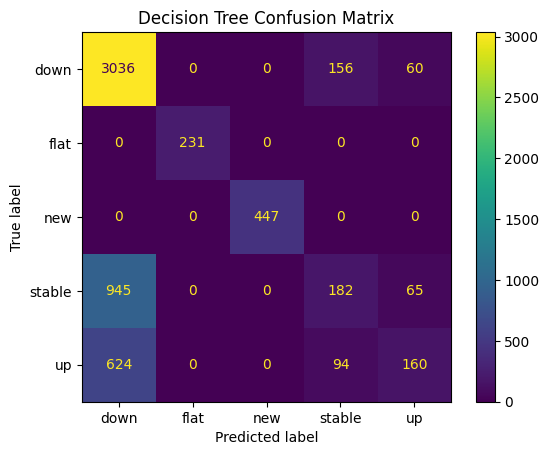

In [36]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.named_steps["tree"].classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.named_steps["tree"].classes_
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()


In [37]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

        down       0.66      0.93      0.77      3252
        flat       1.00      1.00      1.00       231
         new       1.00      1.00      1.00       447
      stable       0.42      0.15      0.22      1192
          up       0.56      0.18      0.28       878

    accuracy                           0.68      6000
   macro avg       0.73      0.65      0.65      6000
weighted avg       0.64      0.68      0.62      6000



In [38]:
errors = X_test.copy()

errors["actual"] = y_test.values
errors["predicted"] = y_pred
errors["correct"] = errors["actual"] == errors["predicted"]

wrong_predictions = errors[~errors["correct"]]

print("Total test rows:", len(errors))
print("Wrong predictions:", len(wrong_predictions))

display(wrong_predictions.head(10))

Total test rows: 6000
Wrong predictions: 1944


,content_age_days,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,...,sessions_prev_30d,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,actual,predicted,correct
25189,329,320.0,0.82,2.71,NaN,NaN,289,1,4,2,...,1,104,0.35,47.8,0.00,0.00,0.0,stable,up,False
6587,225,0.0,0.00,0.00,4285.0,29802.0,23,0,3,3,...,1,20,0.00,5.4,0.00,66.67,0.0,up,down,False
15532,309,30.0,0.01,0.00,3368.0,20253.0,79,0,5,5,...,2,104,0.00,55.6,0.00,20.00,0.0,stable,down,False
20646,98,0.0,0.00,0.00,3258.0,21467.0,20240,29,39,32,...,7,20,0.14,4.1,0.00,5.13,0.0,stable,down,False
4431,141,0.0,0.00,0.00,2717.0,16537.0,4,0,0,1,...,0,8,0.00,10.8,0.00,NaN,0.0,stable,down,False
3420,329,10.0,0.02,0.00,NaN,NaN,6818,36,37,34,...,12,104,0.53,3.4,8.82,10.81,0.0,stable,down,False
1111,179,20.0,0.94,2.99,2712.0,15927.0,191,2,3,4,...,1,20,1.05,6.0,0.00,33.33,0.0,stable,down,False
20218,229,0.0,0.00,0.00,4617.0,30638.0,1263,3,100,60,...,15,104,0.24,27.7,0.00,7.00,0.0,stable,down,False
23822,257,0.0,0.00,0.00,NaN,NaN,3848,4,7,7,...,3,104,0.10,4.6,0.00,0.00,0.0,stable,down,False
14525,112,30.0,0.01,0.00,3089.0,20414.0,20129,99,135,111,...,36,20,0.49,3.4,6.31,9.63,0.0,up,stable,False


In [39]:
print(
    pd.crosstab(
        wrong_predictions["actual"],
        wrong_predictions["predicted"]
    )
)

predicted  down  stable  up
actual                     
down          0     156  60
stable      945       0  65
up          624      94   0


In [40]:
tree = model.named_steps["tree"]

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

display(feature_importance.head(15))

,feature,importance
17,impressions_prev_30d,0.554008
14,impressions_last_30d,0.296859
0,content_age_days,0.060316
15,clicks_last_30d,0.043890
22,avg_position,0.031562
24,scroll_rate,0.013365
2,competition,0.000000
3,cpc,0.000000
4,word_count,0.000000
1,search_volume,0.000000


### Feature interpretation

The Decision Tree relies most heavily on recent search-impression signals. `impressions_prev_30d` has the highest feature importance at 0.554, followed by `impressions_last_30d` at 0.297.

This suggests that changes in recent search visibility are the strongest signals used by the model to distinguish between trend directions. `content_age_days` is the third most important feature with an importance of 0.060, while `avg_position` contributes 0.032.

Most of the remaining features have very low or zero importance in this tree. This does not necessarily mean that those features are useless in general; it only means that this particular Decision Tree did not use them substantially for its learned splits.

The strong reliance on recent impression signals is also consistent with the task because trend direction is related to changes in search performance over time. However, feature importance from a single Decision Tree should not be interpreted as causal evidence.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.